## Custom Rules Visualizer
Plots the 5 custom corrective rule views (CUST1–5) using `visualize_view` from `log_reader.ipynb`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import colors
from pathlib import Path

OUT_DIR = Path("../output/mod_alg")
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
# ---------------------------------------------------------------------------
# Copied from log_reader.ipynb — extended palette to include meta-symbols d, o
# ---------------------------------------------------------------------------
CHAR_PALETTE = {
    'r': '#d62728',   # red robot
    'g': '#2ca02c',   # green robot
    'b': '#1f77b4',   # blue robot
    '.': '#ffffff',   # empty
    'x': '#aaaaaa',   # boundary
    'd': '#ffe0a0',   # EXI — any non-boundary
    'o': '#d0d0ff',   # ANY — any cell including boundary
    '?': '#f0f0f0',   # fallback
}

def char_to_color(ch):
    return CHAR_PALETTE.get(ch, CHAR_PALETTE['?'])


def visualize_view(view13, ax=None, title=None, show=True, annotate_indices=False, fontsize=12):
    """
    From log_reader.ipynb — visualize a 13-element view in the diamond layout.
    ViewIndex order: [U2, UL, U1, UR, L2, L1, C, R1, R2, DL, D1, DR, D2]
    Extended here to colour meta-symbols d (EXI) and o (ANY).
    """
    if len(view13) != 13:
        raise ValueError("view13 must be length 13")

    coords = {
        0:  (2, 0),   # U2
        1:  (1, 1),   # UL
        2:  (2, 1),   # U1
        3:  (3, 1),   # UR
        4:  (0, 2),   # L2
        5:  (1, 2),   # L1
        6:  (2, 2),   # C
        7:  (3, 2),   # R1
        8:  (4, 2),   # R2
        9:  (1, 3),   # DL
        10: (2, 3),   # D1
        11: (3, 3),   # DR
        12: (2, 4),   # D2
    }

    xs = np.array([coords[i][0] for i in range(13)], dtype=float)
    ys = np.array([coords[i][1] for i in range(13)], dtype=float)
    xs = (xs - xs.mean()) * 1.2
    ys = (ys - ys.mean()) * 1.2

    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(4.5, 4.5))
        created_fig = True

    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(title or "2-hop diamond view", fontsize=10, fontweight='bold')

    for idx in range(13):
        ch = view13[idx]
        x = xs[idx]
        y = -ys[idx]
        face = char_to_color(ch)
        # gold ring on center cell
        edge_color = 'gold' if idx == 6 else 'k'
        edge_width = 3    if idx == 6 else 1
        circ = plt.Circle((x, y), 0.35, color=face, ec=edge_color, lw=edge_width)
        ax.add_patch(circ)
        text_color = 'white' if ch in ('r', 'g', 'b') else 'black'
        ax.text(x, y, ch, ha='center', va='center',
                fontsize=fontsize, fontweight='bold', color=text_color)

        if annotate_indices:
            ax.text(x, y - 0.5, str(idx), ha='center', va='center',
                    fontsize=8, color='gray')

    # connect centre to immediate neighbours
    for ni in (2, 5, 7, 10):
        ax.plot([xs[6], xs[ni]], [-ys[6], -ys[ni]], color='k', lw=0.8)

    margin = 1.0
    ax.set_xlim(xs.min() - margin, xs.max() + margin)
    ax.set_ylim(-ys.max() - margin, -ys.min() + margin)

    if created_fig and show:
        plt.tight_layout()
        plt.show()

    return ax

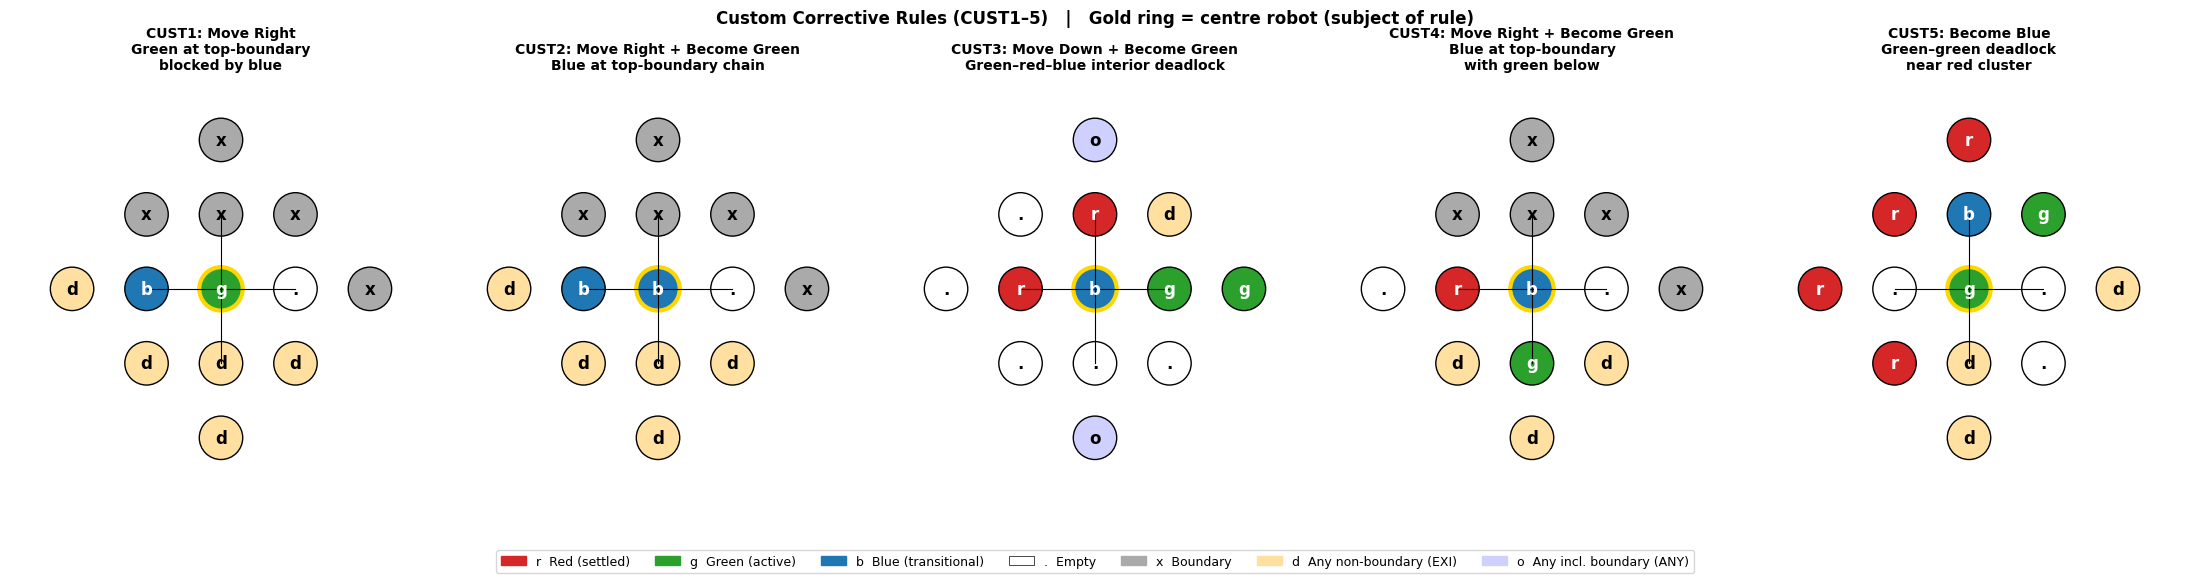

Saved: ../output/mod_alg/custom_rules_visualization.png


In [3]:
# ---------------------------------------------------------------------------
# Custom rules: (pattern string, action title, deadlock description)
# ---------------------------------------------------------------------------
CUSTOM_RULES = [
    ("xxxxdbg.xdddd", "CUST1: Move Right",
     "Green at top-boundary\nblocked by blue"),
    ("xxxxdbb.xdddd", "CUST2: Move Right + Become Green",
     "Blue at top-boundary chain"),
    ("o.rd.rbgg...o", "CUST3: Move Down + Become Green",
     "Green–red–blue interior deadlock"),
    ("xxxx.rb.xdgdd", "CUST4: Move Right + Become Green",
     "Blue at top-boundary\nwith green below"),
    ("rrbgr.g.drd.d", "CUST5: Become Blue",
     "Green–green deadlock\nnear red cluster"),
]

fig, axes = plt.subplots(1, 5, figsize=(22, 5))
fig.suptitle(
    "Custom Corrective Rules (CUST1–5)   |   Gold ring = centre robot (subject of rule)",
    fontsize=12, fontweight='bold', y=1.02
)

for ax, (pattern, action, description) in zip(axes, CUSTOM_RULES):
    visualize_view(
        list(pattern),
        ax=ax,
        title=f"{action}\n{description}",
        show=False
    )

# Legend
legend_elements = [
    mpatches.Patch(color=CHAR_PALETTE['r'], label='r  Red (settled)'),
    mpatches.Patch(color=CHAR_PALETTE['g'], label='g  Green (active)'),
    mpatches.Patch(color=CHAR_PALETTE['b'], label='b  Blue (transitional)'),
    mpatches.Patch(color=CHAR_PALETTE['.'], label='.  Empty', ec='black', lw=0.5),
    mpatches.Patch(color=CHAR_PALETTE['x'], label='x  Boundary'),
    mpatches.Patch(color=CHAR_PALETTE['d'], label='d  Any non-boundary (EXI)'),
    mpatches.Patch(color=CHAR_PALETTE['o'], label='o  Any incl. boundary (ANY)'),
]
fig.legend(
    handles=legend_elements,
    loc='lower center', ncol=7, fontsize=9,
    bbox_to_anchor=(0.5, -0.12)
)

plt.tight_layout()
out_path = OUT_DIR / "custom_rules_visualization.png"
plt.savefig(out_path, dpi=200, bbox_inches='tight')
plt.show()
print("Saved:", out_path)